**Students:** Camille Roy, Kofi Asante
**Section:** A
**Date:** May 3, 2026
**Responsibilities:** We shared the work and both presented.

# CAP3321C Final Project: Miami-Dade Restaurant Inspections

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


## Q1. Cleaning

In [2]:
df = pd.read_csv('mdc_restaurant_inspections_2025.csv')
print(df.shape)

(5171, 8)


In [3]:
df.isna().sum()

zip_code 0
inspection_date 0
cuisine 19
score 32
dtype: int64

There are 32 missing scores. We dropped them.

In [4]:
df = df.dropna(subset=['score'])
df['inspection_date'] = pd.to_datetime(df['inspection_date'])
df = df.drop_duplicates(subset='inspection_id')
print(len(df))

5121


Dates are converted and duplicates are removed, leaving 5,121 inspections. (zip_code is still a number.)

## Q2. Fail rate by ZIP code

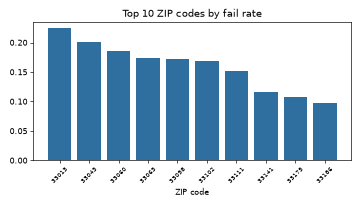

In [5]:
# share of inspections with result == 'Fail', per ZIP
fail_rate = df.assign(fail=df['result'] == 'Fail').groupby('zip_code')['fail'].mean()
top10 = fail_rate.sort_values(ascending=False).head(10)
top10.plot(kind='bar')
plt.show()

ZIP code 33013 has the highest fail rate at 22.4%, about twice the county-wide rate. The top ZIP codes are spread across the county rather than clustered, which suggests the cause is individual restaurants, not one neighborhood.

## Q3. Scores over time

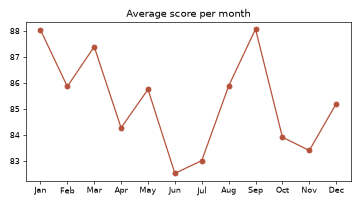

In [6]:
monthly = df.groupby(df['inspection_date'].dt.month)['score'].mean()
monthly.plot(marker='o')
plt.show()

Average scores peak in Sep (88.1) and are lowest in Jun (82.5). The swing is only a few points, so there is no strong seasonal effect, but the dip in Jun lines up with the summer months when kitchens run hotter and busier.

## Q4. Violations by cuisine

In [7]:
per = df.groupby('cuisine')['violations'].mean().sort_values(ascending=False)
per.head(4)

cuisine   violations_per_inspection
Mexican   4.14
Steakhouse3.76
Cuban     3.62
Italian   2.63

Mexican restaurants average 4.14 violations per inspection, nearly 1.6 times Italian. Cuisines with more cooking steps and more ingredient handling have more chances to be cited, so this is likely about process, not quality.